# Actividad 3 | Aprendizaje supervisado y no supervisado

**Dataset:** *eCommerce behavior data from multi category store* — Kaggle  
**Fuente:** `mkechinov/ecommerce-behavior-data-from-multi-category-store`  
  
- Antonio Ramón Valerio Tejada — A01797448  


**Herramienta principal:** PySpark MLlib  


## 1. Introducción teórica

El aprendizaje automático permite identificar patrones en los datos para realizar predicciones o encontrar estructuras ocultas. De forma general, se divide en aprendizaje supervisado y aprendizaje no supervisado.

En el aprendizaje supervisado, los datos incluyen una variable objetivo o etiqueta. El modelo aprende la relación entre las variables de entrada y esa etiqueta para predecir nuevos casos. Algunos algoritmos representativos son árboles de decisión, Random Forest, Gradient Boosted Trees, regresión logística, Naive Bayes y perceptrón multicapa. En PySpark MLlib se pueden implementar mediante clases como `DecisionTreeClassifier`, `RandomForestClassifier`, `GBTClassifier`, `LogisticRegression`, `NaiveBayes` y `MultilayerPerceptronClassifier`.

En el aprendizaje no supervisado, los datos no tienen una etiqueta definida. El objetivo es descubrir patrones, similitudes o grupos naturales dentro de la información. Algunos algoritmos comunes son K-means, Gaussian Mixture Models, Bisecting K-means y Power Iteration Clustering, disponibles en PySpark mediante `KMeans`, `GaussianMixture`, `BisectingKMeans` y `PowerIterationClustering`.

Antes de entrenar los modelos, es necesario construir una muestra representativa, limpiar inconsistencias, transformar variables y dividir los datos en entrenamiento y prueba. En Big Data, este proceso es importante porque trabajar con todo el conjunto puede requerir demasiado tiempo o recursos, por lo que el muestreo ayuda a obtener datos manejables y útiles para el análisis.


## 2. Instalación e importación de librerías

In [ ]:
# Ejecutar solo si tu entorno no tiene estas librerías.
# !pip install pyspark findspark kagglehub pandas matplotlib

In [ ]:
import os
import findspark
findspark.init()

import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator, ClusteringEvaluator

SEED = 42

## 3. Creación de SparkSession

In [ ]:
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("Actividad4_Supervisado_NoSupervisado_eCommerce")
    .config("spark.driver.memory", "8g")
    .config("spark.executor.memory", "8g")
    .config("spark.driver.maxResultSize", "2g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.session.timeZone", "UTC")
    .getOrCreate()
)

# Configuración para visualizar mejor los DataFrames en notebooks.
spark.conf.set("spark.sql.repl.eagerEval.enabled", True)

spark


## 4. Selección de los datos

Para evitar tiempos de procesamiento altos, se construirá una muestra inicial a partir del dataset global.

Estrategia:

1. Descargar o localizar el dataset de Kaggle.
2. Leer únicamente un archivo mensual, preferentemente `2019-Oct.csv`.
3. Tomar una fracción pequeña del dataset completo para trabajar localmente.
4. Generar variables de caracterización.
5. Crear particiones por tipo de evento y segmento de precio.
6. Recuperar un número limitado de instancias por partición para formar la muestra inicial **M**.

In [ ]:
# Descargar el dataset desde Kaggle Hub
import kagglehub

DATASET_DIR = kagglehub.dataset_download("mkechinov/ecommerce-behavior-data-from-multi-category-store")
print("Dataset descargado en:", DATASET_DIR)

csv_path = None
for root, dirs, files in os.walk(DATASET_DIR):
    for file in files:
        if file == "2019-Oct.csv":
            csv_path = os.path.join(root, file)

if csv_path is None:
    raise FileNotFoundError("No se encontró 2019-Oct.csv. Revisa la ruta del dataset.")

print("Archivo seleccionado:", csv_path)

Dataset descargado en: C:\Users\YOLOA\.cache\kagglehub\datasets\mkechinov\ecommerce-behavior-data-from-multi-category-store\versions\8
Archivo seleccionado: C:\Users\YOLOA\.cache\kagglehub\datasets\mkechinov\ecommerce-behavior-data-from-multi-category-store\versions\8\2019-Oct.csv


In [ ]:
# Cargar el archivo CSV en un DataFrame de PySpark
df_raw = spark.read.csv(csv_path, header=True, inferSchema=True)

print("Columnas originales:")
print(df_raw.columns)

df_raw.printSchema()
df_raw.show(5, truncate=False)

Columnas originales:
['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']
root
 |-- event_time: timestamp (nullable = true)
 |-- event_type: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- category_id: long (nullable = true)
 |-- category_code: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- user_session: string (nullable = true)

+-------------------+----------+----------+-------------------+-----------------------------------+--------+-------+---------+------------------------------------+
|event_time         |event_type|product_id|category_id        |category_code                      |brand   |price  |user_id  |user_session                        |
+-------------------+----------+----------+-------------------+-----------------------------------+--------+-------+---------+-------------------------

In [ ]:
# Muestra base para evitar errores de memoria en Spark local.
BASE_SAMPLE_FRACTION = 0.01

df = df_raw.sample(withReplacement=False, fraction=BASE_SAMPLE_FRACTION, seed=SEED)

print("Muestra base creada.")
df.show(5, truncate=False)

Muestra base creada.
+-------------------+----------+----------+-------------------+----------------------+-------+------+---------+------------------------------------+
|event_time         |event_type|product_id|category_id        |category_code         |brand  |price |user_id  |user_session                        |
+-------------------+----------+----------+-------------------+----------------------+-------+------+---------+------------------------------------+
|2019-10-01 00:03:38|view      |5300650   |2053013563173241677|NULL                  |vitek  |12.84 |552584835|b56e1552-5a77-44bc-af49-d1b1ecd00b4e|
|2019-10-01 00:04:45|view      |1004870   |2053013555631882655|electronics.smartphone|samsung|286.86|513881159|387ba75c-47bb-480a-9f86-b7c5cc57cf6b|
|2019-10-01 00:06:19|view      |1004246   |2053013555631882655|electronics.smartphone|apple  |736.18|533940457|309e5dba-628b-491a-98ec-4c2906db831a|
|2019-10-01 00:11:38|view      |9300040   |2053013554524586339|NULL                  

### 4.1 Limpieza inicial y variables de caracterización

Se eliminan registros con nulos en columnas esenciales, se corrigen tipos de datos y se generan variables derivadas:

- `event_date`: fecha del evento.
- `hour`: hora del día.
- `day_of_week`: día de la semana.
- `category_level_1`: categoría principal.
- `price_segment`: segmento de precio definido con cuantiles aproximados.
- `is_purchase`: variable objetivo binaria para el modelo supervisado.

In [ ]:
# Eliminar registros con valores nulos en campos críticos
# y generar variables derivadas para el análisis
df_clean = (
    df
    .dropna(subset=["event_time", "event_type", "product_id", "price", "user_id", "user_session"])
    .filter(F.col("price") >= 0)
    .withColumn("event_date", F.to_date("event_time"))
    .withColumn("hour", F.hour("event_time"))
    .withColumn("day_of_week", F.date_format("event_time", "E"))
    .withColumn(
        "category_level_1",
        F.when(F.col("category_code").isNull(), "unknown")
         .otherwise(F.split(F.col("category_code"), "\\.").getItem(0))
    )
    .withColumn("brand", F.when(F.col("brand").isNull(), "unknown").otherwise(F.col("brand")))
)

q25, q50, q75 = df_clean.approxQuantile("price", [0.25, 0.50, 0.75], 0.05)

df_clean = (
    df_clean
    .withColumn(
        "price_segment",
        F.when(F.col("price") <= q25, "bajo")
         .when(F.col("price") <= q50, "medio_bajo")
         .when(F.col("price") <= q75, "medio_alto")
         .otherwise("alto")
    )
    .withColumn("is_purchase", F.when(F.col("event_type") == "purchase", 1.0).otherwise(0.0))
)

df_clean.select(
    "event_time", "event_type", "price", "hour",
    "day_of_week", "category_level_1", "price_segment", "is_purchase"
).show(10, truncate=False)

+-------------------+----------+------+----+-----------+----------------+-------------+-----------+
|event_time         |event_type|price |hour|day_of_week|category_level_1|price_segment|is_purchase|
+-------------------+----------+------+----+-----------+----------------+-------------+-----------+
|2019-10-01 00:03:38|view      |12.84 |0   |Tue        |unknown         |bajo         |0.0        |
|2019-10-01 00:04:45|view      |286.86|0   |Tue        |electronics     |medio_alto   |0.0        |
|2019-10-01 00:06:19|view      |736.18|0   |Tue        |electronics     |alto         |0.0        |
|2019-10-01 00:11:38|view      |334.12|0   |Tue        |unknown         |alto         |0.0        |
|2019-10-01 01:45:37|view      |177.47|1   |Tue        |electronics     |medio_alto   |0.0        |
|2019-10-01 01:58:12|view      |241.89|1   |Tue        |appliances      |medio_alto   |0.0        |
|2019-10-01 02:00:31|view      |615.19|2   |Tue        |unknown         |alto         |0.0        |


In [ ]:
# Obtener estadísticas generales de la muestra
df_clean.select(
    F.count("*").alias("registros"),
    F.mean("price").alias("precio_promedio"),
    F.min("price").alias("precio_minimo"),
    F.max("price").alias("precio_maximo")
).show()

print("Distribución de event_type:")
df_clean.groupBy("event_type").count().orderBy(F.desc("count")).show(truncate=False)

print("Distribución de price_segment:")
df_clean.groupBy("price_segment").count().orderBy(F.desc("count")).show(truncate=False)

print("Distribución de category_level_1:")
df_clean.groupBy("category_level_1").count().orderBy(F.desc("count")).show(10, truncate=False)

+---------+------------------+-------------+-------------+
|registros|   precio_promedio|precio_minimo|precio_maximo|
+---------+------------------+-------------+-------------+
|   425322|291.56316019392347|          0.0|      2574.07|
+---------+------------------+-------------+-------------+

Distribución de event_type:
+----------+------+
|event_type|count |
+----------+------+
|view      |408827|
|cart      |9110  |
|purchase  |7385  |
+----------+------+

Distribución de price_segment:
+-------------+------+
|price_segment|count |
+-------------+------+
|alto         |120992|
|bajo         |107066|
|medio_alto   |101094|
|medio_bajo   |96170 |
+-------------+------+

Distribución de category_level_1:
+----------------+------+
|category_level_1|count |
+----------------+------+
|electronics     |162028|
|unknown         |135517|
|appliances      |49603 |
|computers       |23468 |
|apparel         |15331 |
|furniture       |12465 |
|auto            |9929  |
|construction    |7310  |

### Revisión de valores atípicos

Para identificar posibles valores atípicos, se revisó principalmente la variable `price`, ya que es la variable numérica con mayor impacto en los modelos. Durante la limpieza se eliminaron precios negativos por considerarse inconsistentes. Los valores altos se conservaron, ya que pueden corresponder a productos reales de mayor costo, especialmente en categorías como electrónica.

Además, se creó la variable `price_segment` mediante cuantiles, lo que permite reducir el efecto de la dispersión del precio y analizar los productos por rangos en lugar de depender únicamente del valor numérico original.

### 4.2 Generación de la muestra de trabajo

Para construir la muestra **M**, se utiliza una selección controlada de registros considerando dos variables relevantes del comportamiento de compra:

* `event_type`
* `price_segment`

La combinación de estas variables permite incluir distintos tipos de interacción del usuario y diferentes rangos de precio dentro de la muestra. Dado que los eventos no aparecen con la misma frecuencia en el dataset original, se establece un límite de registros por grupo para evitar que los eventos más comunes tengan un peso excesivo en el conjunto final.

Esta muestra no pretende replicar exactamente la distribución completa de la base original, sino generar un subconjunto equilibrado y manejable que permita probar los algoritmos de aprendizaje supervisado y no supervisado en PySpark.



In [ ]:
# Crear una etiqueta que combine el tipo de evento y el segmento de precio
df_part = (
    df_clean
    .withColumn(
        "partition_rule",
        F.concat_ws("_", F.col("event_type"), F.col("price_segment"))
    )
)

partition_counts = (
    df_part
    .groupBy("partition_rule")
    .count()
    .orderBy(F.desc("count"))
)

partition_counts.show(50, truncate=False)

+-------------------+------+
|partition_rule     |count |
+-------------------+------+
|view_alto          |115937|
|view_bajo          |104225|
|view_medio_alto    |96090 |
|view_medio_bajo    |92575 |
|cart_medio_alto    |2977  |
|cart_alto          |2861  |
|purchase_alto      |2194  |
|purchase_medio_alto|2027  |
|cart_medio_bajo    |1997  |
|purchase_medio_bajo|1598  |
|purchase_bajo      |1566  |
|cart_bajo          |1275  |
+-------------------+------+



In [ ]:
#Construcción de la muestra M
N_PER_PARTITION = 600

allocation = (
    partition_counts
    .withColumn(
        "fraccion_muestreo",
        F.when(F.col("count") <= N_PER_PARTITION, F.lit(1.0))
         .otherwise(F.lit(N_PER_PARTITION) / F.col("count"))
    )
)

fractions = {
    row["partition_rule"]: min(float(row["fraccion_muestreo"]), 1.0)
    for row in allocation.collect()
}

M = df_part.sampleBy("partition_rule", fractions=fractions, seed=SEED)

print("Muestra M creada.")
print(f"Tamaño aproximado de M: {M.count():,}")

print("Distribución de la muestra M por partición:")
M.groupBy("partition_rule").count().orderBy(F.desc("count")).show(50, truncate=False)

print("Distribución de la variable objetivo en M:")
M.groupBy("is_purchase").count().orderBy("is_purchase").show()


Muestra M creada.
Tamaño aproximado de M: 7,298
Distribución de la muestra M por partición:
+-------------------+-----+
|partition_rule     |count|
+-------------------+-----+
|view_medio_alto    |656  |
|cart_medio_alto    |642  |
|view_bajo          |631  |
|cart_bajo          |619  |
|purchase_medio_bajo|619  |
|cart_alto          |618  |
|purchase_medio_alto|601  |
|purchase_bajo      |593  |
|cart_medio_bajo    |582  |
|view_alto          |582  |
|purchase_alto      |581  |
|view_medio_bajo    |574  |
+-------------------+-----+

Distribución de la variable objetivo en M:
+-----------+-----+
|is_purchase|count|
+-----------+-----+
|        0.0| 4904|
|        1.0| 2394|
+-----------+-----+



## 5. Preparación de la muestra para modelado

Antes de aplicar los algoritmos de aprendizaje automático, fue necesario realizar una serie de transformaciones para asegurar que los datos pudieran ser procesados correctamente por las herramientas de PySpark MLlib.

Las principales actividades realizadas fueron:

* Eliminación de registros con información incompleta o inconsistente.
* Tratamiento de valores faltantes en variables categóricas.
* Codificación de variables categóricas a formato numérico mediante técnicas de indexación y codificación binaria.
* Integración de las variables seleccionadas en un único vector de características (`features`).
* Definición de la variable objetivo `is_purchase`, utilizada para identificar si una interacción terminó en compra o no.

Como resultado, se obtuvo un conjunto de datos estructurado y listo para la construcción de modelos de aprendizaje supervisado y no supervisado.


In [ ]:
# Selección y preparación de variables predictoras
model_cols = [
    "price",
    "hour",
    "event_type",
    "category_level_1",
    "brand",
    "price_segment",
    "day_of_week",
    "is_purchase",
    "partition_rule"
]

M_model = (
    M
    .select(*model_cols)
    .dropna(subset=["price", "hour", "is_purchase"])
)

# Limitar marcas para evitar demasiadas categorías.
top_brands = [
    row["brand"]
    for row in M_model.groupBy("brand").count().orderBy(F.desc("count")).limit(25).collect()
]

M_model = M_model.withColumn(
    "brand_limited",
    F.when(F.col("brand").isin(top_brands), F.col("brand")).otherwise("other")
)

M_model.select(
    "price", "hour", "event_type", "category_level_1",
    "brand_limited", "price_segment", "day_of_week", "is_purchase"
).show(10, truncate=False)

+-------+----+----------+----------------+-------------+-------------+-----------+-----------+
|price  |hour|event_type|category_level_1|brand_limited|price_segment|day_of_week|is_purchase|
+-------+----+----------+----------------+-------------+-------------+-----------+-----------+
|65.38  |2   |view      |unknown         |other        |bajo         |Tue        |0.0        |
|130.76 |3   |view      |electronics     |samsung      |medio_bajo   |Tue        |0.0        |
|56.23  |3   |purchase  |appliances      |redmond      |bajo         |Tue        |1.0        |
|39.9   |3   |cart      |unknown         |other        |bajo         |Tue        |0.0        |
|82.29  |3   |purchase  |auto            |other        |medio_bajo   |Tue        |1.0        |
|1415.48|3   |cart      |electronics     |apple        |alto         |Tue        |0.0        |
|17.99  |3   |purchase  |appliances      |other        |bajo         |Tue        |1.0        |
|391.0  |3   |purchase  |unknown         |sony    

In [ ]:
#Distribución de la variable objetivo
target_distribution = (
    M_model
    .groupBy("is_purchase")
    .count()
    .withColumn("porcentaje", F.round(F.col("count") / F.sum("count").over(Window.partitionBy()) * 100, 2))
)

target_distribution.show()

+-----------+-----+----------+
|is_purchase|count|porcentaje|
+-----------+-----+----------+
|        1.0| 2394|      32.8|
|        0.0| 4904|      67.2|
+-----------+-----+----------+



### 5.1 Consideraciones sobre la muestra utilizada

La muestra **M** se generó mediante una selección controlada por grupos, con el propósito de incluir suficientes registros de eventos menos frecuentes, como las compras. Debido a esto, la distribución de la muestra puede diferir de la distribución original del dataset completo.

Esta decisión resulta adecuada para fines de experimentación y entrenamiento de modelos, ya que permite trabajar con más ejemplos de la clase minoritaria. Sin embargo, los porcentajes obtenidos en **M** no deben interpretarse como tasas reales de conversión del negocio. Para calcular proporciones poblacionales sería necesario utilizar una muestra proporcional al dataset original o aplicar ponderaciones según el tamaño de cada grupo.


## 6. División de datos para entrenamiento y prueba

Para evaluar el desempeño del modelo supervisado, la muestra se divide en dos subconjuntos: entrenamiento y prueba. Se utiliza una proporción **80/20**, donde el 80% de los datos se emplea para entrenar el modelo y el 20% restante para evaluar su comportamiento con registros no vistos.

La separación se realiza de forma estratificada tomando como referencia la variable `is_purchase`. De esta manera, tanto el conjunto de entrenamiento como el de prueba conservan una distribución similar de compras y no compras.

Adicionalmente, se calculan pesos de clase a partir del conjunto de entrenamiento. Esto ayuda a compensar el desbalance entre clases y evita que el modelo favorezca excesivamente la clase con mayor cantidad de registros.


In [ ]:
# División estratificada 80/20 usando la variable objetivo is_purchase.
# Esto ayuda a mantener una proporción similar de compras y no compras en train y test.

M_indexed = M_model.withColumn("row_id", F.monotonically_increasing_id())

train_fraction_by_class = {
    0.0: 0.80,
    1.0: 0.80
}

train = M_indexed.sampleBy(
    "is_purchase",
    fractions=train_fraction_by_class,
    seed=SEED
)

train_ids = train.select("row_id").withColumn("in_train", F.lit(1))

test = (
    M_indexed
    .join(train_ids, on="row_id", how="left")
    .filter(F.col("in_train").isNull())
    .drop("in_train")
)

print(f"Train: {train.count():,}")
print(f"Test: {test.count():,}")

print("Distribución en entrenamiento:")
train.groupBy("is_purchase").count().orderBy("is_purchase").show()

print("Distribución en prueba:")
test.groupBy("is_purchase").count().orderBy("is_purchase").show()

# Cálculo de pesos de clase a partir del conjunto de entrenamiento.
# Esto es importante porque, sin pesos, el modelo puede favorecer la clase mayoritaria.
class_counts = {
    row["is_purchase"]: row["count"]
    for row in train.groupBy("is_purchase").count().collect()
}

n_train = sum(class_counts.values())

weight_0 = n_train / (2 * class_counts.get(0.0, 1))
weight_1 = n_train / (2 * class_counts.get(1.0, 1))

train = train.withColumn(
    "class_weight",
    F.when(F.col("is_purchase") == 1.0, F.lit(weight_1)).otherwise(F.lit(weight_0))
)

test = test.withColumn(
    "class_weight",
    F.when(F.col("is_purchase") == 1.0, F.lit(weight_1)).otherwise(F.lit(weight_0))
)

print(f"Peso clase 0: {weight_0:.4f}")
print(f"Peso clase 1: {weight_1:.4f}")


Train: 5,838
Test: 1,460
Distribución en entrenamiento:
+-----------+-----+
|is_purchase|count|
+-----------+-----+
|        0.0| 3924|
|        1.0| 1914|
+-----------+-----+

Distribución en prueba:
+-----------+-----+
|is_purchase|count|
+-----------+-----+
|        0.0|  980|
|        1.0|  480|
+-----------+-----+

Peso clase 0: 0.7439
Peso clase 1: 1.5251


## 7. Implementación del modelo supervisado

Para la tarea de clasificación se seleccionó el algoritmo **Random Forest Classifier**, cuyo objetivo es predecir si una interacción de usuario termina en una compra (`is_purchase = 1`) o en otro tipo de evento (`is_purchase = 0`).

Durante la construcción del modelo se excluyó la variable `event_type` del conjunto de predictores, ya que la variable objetivo fue generada a partir de dicha información. Esto permite evitar dependencias directas entre las variables de entrada y la etiqueta a predecir.

Adicionalmente, se incorporaron pesos de clase con el fin de reducir el impacto del desbalance existente entre compras y no compras, favoreciendo una evaluación más equilibrada del desempeño del modelo.



In [ ]:
### Entrenamiento del modelo Random Forest
categorical_cols = [
    "category_level_1",
    "brand_limited",
    "price_segment",
    "day_of_week"
]

numeric_cols = [
    "price",
    "hour"
]

indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="keep")
    for col in categorical_cols
]

encoder = OneHotEncoder(
    inputCols=[f"{col}_idx" for col in categorical_cols],
    outputCols=[f"{col}_ohe" for col in categorical_cols],
    handleInvalid="keep"
)

assembler = VectorAssembler(
    inputCols=numeric_cols + [f"{col}_ohe" for col in categorical_cols],
    outputCol="features",
    handleInvalid="keep"
)

rf = RandomForestClassifier(
    labelCol="is_purchase",
    featuresCol="features",
    weightCol="class_weight",
    numTrees=80,
    maxDepth=7,
    minInstancesPerNode=5,
    seed=SEED
)

rf_pipeline = Pipeline(stages=indexers + [encoder, assembler, rf])

rf_model = rf_pipeline.fit(train)
predictions = rf_model.transform(test)

predictions.select(
    "is_purchase", "prediction", "probability",
    "price", "hour", "category_level_1", "brand_limited", "price_segment"
).show(20, truncate=False)


+-----------+----------+----------------------------------------+------+----+----------------+-------------+-------------+
|is_purchase|prediction|probability                             |price |hour|category_level_1|brand_limited|price_segment|
+-----------+----------+----------------------------------------+------+----+----------------+-------------+-------------+
|1.0        |0.0       |[0.5294815774398637,0.4705184225601363] |56.23 |3   |appliances      |redmond      |bajo         |
|1.0        |0.0       |[0.5131821319198343,0.4868178680801657] |17.99 |3   |appliances      |other        |bajo         |
|0.0        |0.0       |[0.5120844110570075,0.4879155889429924] |19.82 |3   |unknown         |vitek        |bajo         |
|1.0        |0.0       |[0.5146858154047722,0.4853141845952277] |476.18|4   |appliances      |samsung      |alto         |
|0.0        |1.0       |[0.47875982684552226,0.5212401731544778]|174.75|4   |electronics     |samsung      |medio_alto   |
|1.0        |1.0

In [ ]:
### Evaluación del desempeño del modelo
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="is_purchase",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="is_purchase",
    predictionCol="prediction",
    metricName="accuracy"
)

f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="is_purchase",
    predictionCol="prediction",
    metricName="f1"
)

precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="is_purchase",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="is_purchase",
    predictionCol="prediction",
    metricName="weightedRecall"
)

auc = auc_evaluator.evaluate(predictions)
accuracy = accuracy_evaluator.evaluate(predictions)
f1 = f1_evaluator.evaluate(predictions)
precision = precision_evaluator.evaluate(predictions)
recall = recall_evaluator.evaluate(predictions)

print(f"AUC: {auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score ponderado: {f1:.4f}")
print(f"Precisión ponderada: {precision:.4f}")
print(f"Recall ponderado: {recall:.4f}")

# Métricas específicas para la clase positiva: purchase = 1.
cm = (
    predictions
    .groupBy("is_purchase", "prediction")
    .count()
    .toPandas()
)

tp = cm[(cm["is_purchase"] == 1.0) & (cm["prediction"] == 1.0)]["count"].sum()
fn = cm[(cm["is_purchase"] == 1.0) & (cm["prediction"] == 0.0)]["count"].sum()
fp = cm[(cm["is_purchase"] == 0.0) & (cm["prediction"] == 1.0)]["count"].sum()
tn = cm[(cm["is_purchase"] == 0.0) & (cm["prediction"] == 0.0)]["count"].sum()

precision_pos = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_pos = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_pos = 2 * precision_pos * recall_pos / (precision_pos + recall_pos) if (precision_pos + recall_pos) > 0 else 0

print(f"Precision clase purchase: {precision_pos:.4f}")
print(f"Recall clase purchase: {recall_pos:.4f}")
print(f"F1 clase purchase: {f1_pos:.4f}")

if tp == 0:
    print("Advertencia: el modelo no detectó compras. Se recomienda ajustar más el balanceo, probar GBTClassifier o usar más variables predictoras.")


AUC: 0.5526
Accuracy: 0.5377
F1-score ponderado: 0.5516
Precisión ponderada: 0.5901
Recall ponderado: 0.5377
Precision clase purchase: 0.3617
Recall clase purchase: 0.5312
F1 clase purchase: 0.4304


In [ ]:
# Matriz de confusión
confusion_matrix = (
    predictions
    .groupBy("is_purchase", "prediction")
    .count()
    .orderBy("is_purchase", "prediction")
)

confusion_matrix.show()

+-----------+----------+-----+
|is_purchase|prediction|count|
+-----------+----------+-----+
|        0.0|       0.0|  530|
|        0.0|       1.0|  450|
|        1.0|       0.0|  225|
|        1.0|       1.0|  255|
+-----------+----------+-----+



### 7.1 Interpretación de resultados del modelo supervisado

El modelo **Random Forest** se utilizó como una primera aproximación para clasificar los eventos de la muestra en dos grupos: compras y no compras. Aunque el modelo logra generar predicciones para ambas clases, los resultados indican que todavía existe margen de mejora en su capacidad predictiva.

En la evaluación del conjunto de prueba se obtuvieron los siguientes valores aproximados:

* **AUC:** 0.5526
* **Accuracy:** 0.5377
* **F1 ponderado:** 0.5516
* **Precision clase purchase:** 0.3617
* **Recall clase purchase:** 0.5312
* **F1 clase purchase:** 0.4304

Estos resultados muestran que el modelo identifica una parte de los eventos de compra, pero también clasifica incorrectamente varios eventos que en realidad no terminaron en compra. Por ello, el modelo puede considerarse útil como punto de partida, aunque no como una solución definitiva para predecir conversiones.

Una posible razón de este desempeño es que las variables utilizadas describen principalmente características aisladas del evento, como precio, hora, categoría, marca y día de la semana. Sin embargo, la decisión de compra suele depender también del comportamiento previo del usuario dentro de la sesión. Para mejorar el modelo, podrían agregarse variables como número de vistas anteriores, eventos agregados al carrito, duración de la sesión, historial del usuario o secuencia de interacciones antes de la compra.

En conclusión, el modelo supervisado funciona como una línea base implementada en PySpark. Su principal aportación es demostrar el proceso completo de preparación de datos, entrenamiento, predicción y evaluación, dejando abierta la posibilidad de mejorar el desempeño mediante nuevas variables y ajustes adicionales.


## 8. Implementación del modelo no supervisado

Para el análisis no supervisado se seleccionó el algoritmo **K-means**, con el propósito de identificar grupos de registros con características similares sin utilizar la variable objetivo `is_purchase`.

Las variables consideradas para el agrupamiento fueron:

* `price`
* `hour`
* `category_level_1`
* `brand_limited`
* `day_of_week`

En este modelo no se incluyó `price_segment`, ya que esta variable se deriva directamente de `price`. Mantener ambas podría dar un peso excesivo al precio dentro del proceso de agrupamiento y afectar la formación de los clusters.

Para definir la configuración principal del modelo, se compararon diferentes valores de `k`. A partir de esta revisión, se seleccionó **k = 2**, ya que ofreció una separación más adecuada entre los grupos en comparación con otras opciones evaluadas.

La calidad del agrupamiento se evaluará mediante el **Silhouette Score**, métrica que permite analizar qué tan bien separados se encuentran los clusters generados.


### 8.1 Consideraciones del modelo K-means

El algoritmo **K-means** permite formar grupos de observaciones con base en la similitud de sus características. Para ello, cada registro debe representarse mediante un vector numérico, por lo que las variables categóricas se transforman previamente antes de aplicar el modelo.

Debido a que K-means se basa en distancias, las variables numéricas pueden influir de manera importante en la formación de los grupos. Por esta razón, se aplica escalamiento para reducir diferencias de magnitud entre variables y favorecer una comparación más equilibrada.

También es importante señalar que las variables categóricas codificadas ayudan a incluir información como categoría, marca y día de la semana, aunque no necesariamente representan todas las relaciones reales entre los productos o comportamientos de los usuarios.

Por lo anterior, los clusters obtenidos deben interpretarse como una exploración inicial de patrones dentro de la muestra, no como una segmentación definitiva del comportamiento de compra.



In [ ]:
# Para clustering se excluye price_segment porque se deriva directamente de price.
# Esto evita duplicar el peso del precio dentro de la distancia euclidiana de K-means.

cluster_categorical_cols = [
    "category_level_1",
    "brand_limited",
    "day_of_week"
]

cluster_numeric_cols = [
    "price",
    "hour"
]

cluster_indexers = [
    StringIndexer(inputCol=col, outputCol=f"cluster_{col}_idx", handleInvalid="keep")
    for col in cluster_categorical_cols
]

cluster_encoder = OneHotEncoder(
    inputCols=[f"cluster_{col}_idx" for col in cluster_categorical_cols],
    outputCols=[f"cluster_{col}_ohe" for col in cluster_categorical_cols],
    handleInvalid="keep"
)

cluster_assembler = VectorAssembler(
    inputCols=cluster_numeric_cols + [f"cluster_{col}_ohe" for col in cluster_categorical_cols],
    outputCol="cluster_features_raw",
    handleInvalid="keep"
)

cluster_scaler = StandardScaler(
    inputCol="cluster_features_raw",
    outputCol="cluster_features",
    withStd=True,
    withMean=False
)

K_SELECTED = 2

kmeans = KMeans(
    featuresCol="cluster_features",
    predictionCol="cluster",
    k=K_SELECTED,
    seed=SEED,
    maxIter=20
)

kmeans_pipeline = Pipeline(
    stages=cluster_indexers + [cluster_encoder, cluster_assembler, cluster_scaler, kmeans]
)

kmeans_model = kmeans_pipeline.fit(M_model)
clustered = kmeans_model.transform(M_model)

clustered.select(
    "price", "hour", "category_level_1", "brand_limited",
    "price_segment", "day_of_week", "cluster"
).show(20, truncate=False)


+-------+----+----------------+-------------+-------------+-----------+-------+
|price  |hour|category_level_1|brand_limited|price_segment|day_of_week|cluster|
+-------+----+----------------+-------------+-------------+-----------+-------+
|65.38  |2   |unknown         |other        |bajo         |Tue        |1      |
|130.76 |3   |electronics     |samsung      |medio_bajo   |Tue        |0      |
|56.23  |3   |appliances      |redmond      |bajo         |Tue        |1      |
|39.9   |3   |unknown         |other        |bajo         |Tue        |1      |
|82.29  |3   |auto            |other        |medio_bajo   |Tue        |1      |
|1415.48|3   |electronics     |apple        |alto         |Tue        |0      |
|17.99  |3   |appliances      |other        |bajo         |Tue        |1      |
|391.0  |3   |unknown         |sony         |alto         |Tue        |1      |
|19.82  |3   |unknown         |vitek        |bajo         |Tue        |1      |
|46.33  |3   |auto            |other    

### 8.2 Visualización de los grupos obtenidos

Para analizar los resultados del modelo K-means, se genera una gráfica que relaciona el **precio** con una representación numérica de la **categoría del producto**. Esta comparación permite observar si los clusters tienden a concentrarse en ciertos rangos de precio o en determinados grupos de categorías.

Es importante considerar que la categoría codificada se utiliza únicamente con fines de visualización. Sus valores no representan un orden real entre categorías, sino identificadores numéricos generados durante el procesamiento. Por esta razón, la gráfica debe interpretarse como un apoyo exploratorio para entender la separación de los grupos, no como una relación ordinal directa entre categorías.


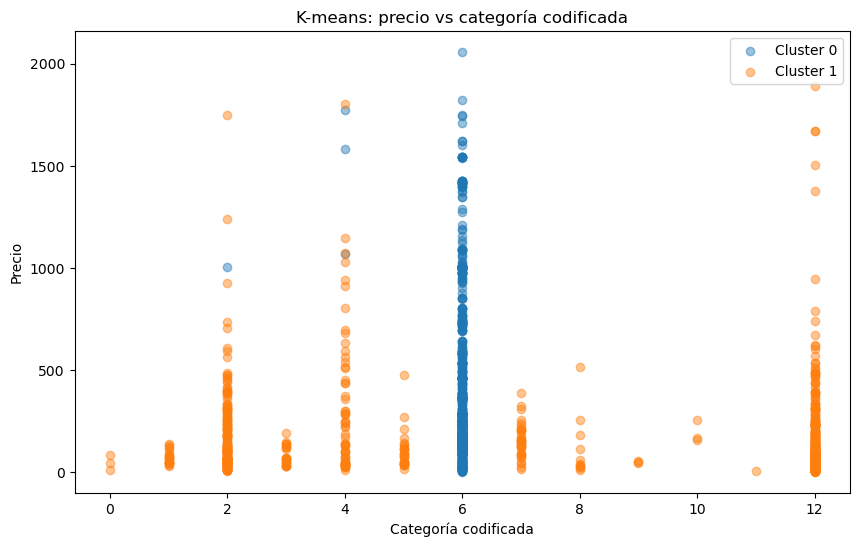

,category_level_1,category_idx
0,accessories,0
1,apparel,1
2,appliances,2
3,auto,3
4,computers,4
5,construction,5
6,electronics,6
7,furniture,7
8,kids,8
9,medicine,9


In [ ]:
# Visualización principal: precio vs categoría codificada por cluster

import matplotlib.pyplot as plt
import pandas as pd

viz_df = clustered.select(
    "price",
    "cluster",
    "category_level_1"
).sample(False, 0.25, seed=SEED).toPandas()

category_map = {
    cat: idx
    for idx, cat in enumerate(sorted(viz_df["category_level_1"].astype(str).unique()))
}

viz_df["category_idx"] = viz_df["category_level_1"].astype(str).map(category_map)

plt.figure(figsize=(10, 6))

for cluster_id in sorted(viz_df["cluster"].unique()):
    subset = viz_df[viz_df["cluster"] == cluster_id]
    plt.scatter(
        subset["category_idx"],
        subset["price"],
        alpha=0.45,
        label=f"Cluster {cluster_id}"
    )

plt.xlabel("Categoría codificada")
plt.ylabel("Precio")
plt.title("K-means: precio vs categoría codificada")
plt.legend()
plt.show()

# Tabla auxiliar para interpretar los códigos de categoría
category_lookup = pd.DataFrame(
    list(category_map.items()),
    columns=["category_level_1", "category_idx"]
).sort_values("category_idx")

category_lookup


### 8.3 Análisis de la gráfica de clusters

La visualización permite observar que los grupos generados por K-means presentan diferencias principalmente asociadas con el precio y ciertas categorías de producto. En particular, uno de los clusters concentra una mayor presencia de productos de electrónica con precios más elevados, mientras que el otro agrupa registros más diversos y con valores de precio generalmente menores o más dispersos.

Sin embargo, la separación entre clusters no es completamente clara. Esto es consistente con el valor bajo del **Silhouette Score**, lo que indica que los grupos formados no están fuertemente separados entre sí. Por esta razón, la gráfica debe considerarse como una herramienta de apoyo para explorar patrones generales, no como una segmentación definitiva.

La variable de categoría codificada se utiliza únicamente para facilitar la visualización y no debe interpretarse como una escala jerárquica u ordinal.


In [ ]:
# Calcular el Silhouette Score para evaluar la calidad del agrupamiento
clustering_evaluator = ClusteringEvaluator(
    featuresCol="cluster_features",
    predictionCol="cluster",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

silhouette = clustering_evaluator.evaluate(clustered)

print(f"Silhouette score: {silhouette:.4f}")

# Mostrar cuántos registros fueron asignados a cada cluster
print("Tamaño de cada cluster:")
clustered.groupBy("cluster").count().orderBy("cluster").show()

# Obtener estadísticas promedio para describir cada grupo
print("Perfil promedio por cluster:")
clustered.groupBy("cluster").agg(
    F.count("*").alias("registros"),
    F.round(F.mean("price"), 2).alias("precio_promedio"),
    F.round(F.mean("hour"), 2).alias("hora_promedio"),
    F.round(F.mean("is_purchase"), 4).alias("proporcion_purchase")
).orderBy("cluster").show()

Silhouette score: 0.1446
Tamaño de cada cluster:
+-------+-----+
|cluster|count|
+-------+-----+
|      0| 3836|
|      1| 3462|
+-------+-----+

Perfil promedio por cluster:
+-------+---------+---------------+-------------+-------------------+
|cluster|registros|precio_promedio|hora_promedio|proporcion_purchase|
+-------+---------+---------------+-------------+-------------------+
|      0|     3836|         378.14|        10.57|             0.3428|
|      1|     3462|         158.76|         10.5|             0.3117|
+-------+---------+---------------+-------------+-------------------+



In [ ]:
print("Distribución de segmentos de precio por cluster:")
clustered.groupBy("cluster", "price_segment").count().orderBy("cluster", F.desc("count")).show(50, truncate=False)

print("Distribución de categorías principales por cluster:")
clustered.groupBy("cluster", "category_level_1").count().orderBy("cluster", F.desc("count")).show(50, truncate=False)

Distribución de segmentos de precio por cluster:
+-------+-------------+-----+
|cluster|price_segment|count|
+-------+-------------+-----+
|0      |medio_alto   |1344 |
|0      |alto         |1319 |
|0      |medio_bajo   |893  |
|0      |bajo         |280  |
|1      |bajo         |1563 |
|1      |medio_bajo   |882  |
|1      |medio_alto   |555  |
|1      |alto         |462  |
+-------+-------------+-----+

Distribución de categorías principales por cluster:
+-------+----------------+-----+
|cluster|category_level_1|count|
+-------+----------------+-----+
|0      |electronics     |3822 |
|0      |computers       |9    |
|0      |appliances      |4    |
|0      |sport           |1    |
|1      |unknown         |1766 |
|1      |appliances      |835  |
|1      |computers       |265  |
|1      |auto            |126  |
|1      |apparel         |125  |
|1      |construction    |125  |
|1      |furniture       |118  |
|1      |kids            |64   |
|1      |sport           |15   |
|1      |a

### 8.4 Interpretación del modelo no supervisado

El modelo **K-means** permitió agrupar los registros de acuerdo con características como precio, hora del evento, categoría, marca y día de la semana. Para la versión final se utilizó **k = 2**, ya que este valor presentó el mejor resultado dentro de la comparación realizada con diferentes números de clusters.

Los resultados principales fueron los siguientes:

* **Silhouette Score con k = 2:** aproximadamente 0.1446
* **Cluster 0:** 3,836 registros
* **Cluster 1:** 3,462 registros
* **Precio promedio del cluster 0:** aproximadamente 378.14
* **Precio promedio del cluster 1:** aproximadamente 158.76
* **Proporción de compra del cluster 0:** aproximadamente 0.3428
* **Proporción de compra del cluster 1:** aproximadamente 0.3117

Aunque el Silhouette Score es positivo, su valor es bajo. Esto sugiere que los clusters presentan cierta separación, pero no de manera fuerte. Por lo tanto, los grupos obtenidos deben analizarse como una segmentación exploratoria y no como una clasificación definitiva de usuarios o productos.

El **cluster 0** se caracteriza por concentrar registros con precios promedio más altos y una presencia importante de productos de electrónica. Por otro lado, el **cluster 1** agrupa registros con menor precio promedio y mayor variedad de categorías, como productos sin categoría identificada, electrodomésticos, computadoras, artículos de auto, ropa, construcción y muebles.

La comparación con otros valores de `k` mostró que aumentar el número de clusters no mejoró la calidad del agrupamiento. En algunos casos, los valores de Silhouette fueron menores o negativos, lo que indica que los grupos se vuelven menos definidos.

En general, K-means permitió identificar una separación inicial asociada principalmente con el precio y la categoría del producto. Sin embargo, debido al bajo nivel de separación y al uso de variables categóricas codificadas, los resultados deben interpretarse con cautela.


## 9. Comparación de diferentes valores de k

Esta sección permite verificar si el valor seleccionado de k tiene sentido. Durante la evaluación de diferentes valores de k, k=2 obtuvo el mejor Silhouette Score, por lo que se eligió para el modelo principal.


In [ ]:
# Comparación de diferentes valores de k sobre la misma muestra M_model completa.
# Esto evita contradicciones entre el modelo principal y la comparación rápida.

k_values = [2, 3, 4, 5, 6]
silhouette_results = []

for k in k_values:
    km = KMeans(
        featuresCol="cluster_features",
        predictionCol="cluster",
        k=k,
        seed=SEED,
        maxIter=15
    )

    pipeline_k = Pipeline(
        stages=cluster_indexers + [cluster_encoder, cluster_assembler, cluster_scaler, km]
    )

    model_k = pipeline_k.fit(M_model)
    pred_k = model_k.transform(M_model)

    score = clustering_evaluator.evaluate(pred_k)
    silhouette_results.append((k, score))

silhouette_df = spark.createDataFrame(silhouette_results, ["k", "silhouette"])
silhouette_df.orderBy(F.desc("silhouette")).show()


+---+--------------------+
|  k|          silhouette|
+---+--------------------+
|  2| 0.14455837685715148|
|  5|0.009445564465565746|
|  6|-0.00681572162970...|
|  4|-0.08073079068143948|
|  3|-0.10895379778905719|
+---+--------------------+



## 10. Exportación opcional de resultados

Spark puede tener problemas para exportar CSV en Windows por dependencias de Hadoop/winutils. Por eso, si se desea guardar una muestra pequeña de resultados, se exporta con Pandas.

In [ ]:
# Exportación de resultados
OUTPUT_DIR = "actividad3_resultados"
os.makedirs(OUTPUT_DIR, exist_ok=True)

predictions_export = (
    predictions
    .select(
        "price", "hour", "category_level_1", "brand_limited",
        "price_segment", "day_of_week", "is_purchase", "prediction"
    )
    .limit(1000)
    .toPandas()
)

predictions_export.to_csv(
    os.path.join(OUTPUT_DIR, "predicciones_random_forest.csv"),
    index=False,
    encoding="utf-8-sig"
)

clusters_export = (
    clustered
    .select(
        "price", "hour", "category_level_1", "brand_limited",
        "price_segment", "day_of_week", "cluster"
    )
    .limit(1000)
    .toPandas()
)

clusters_export.to_csv(
    os.path.join(OUTPUT_DIR, "clusters_kmeans.csv"),
    index=False,
    encoding="utf-8-sig"
)

print(f"Archivos exportados en: {OUTPUT_DIR}")


Archivos exportados en: actividad4_resultados


## 11. Conclusiones

El desarrollo de esta actividad permitió aplicar de manera práctica las etapas principales de un flujo de aprendizaje automático utilizando PySpark. A partir de un conjunto de datos de comercio electrónico, se seleccionó una muestra de trabajo que permitió reducir el volumen de procesamiento y, al mismo tiempo, conservar registros representativos de distintos tipos de eventos y rangos de precio.

Durante la preparación de los datos se realizaron transformaciones necesarias para convertir la información original en un formato adecuado para los modelos. Entre estas transformaciones se incluyeron la limpieza de registros incompletos, la creación de variables derivadas, la codificación de variables categóricas y la integración de los atributos en vectores de características. Este proceso fue fundamental, ya que los algoritmos de MLlib requieren datos estructurados y numéricos para poder entrenarse correctamente.

En el modelo supervisado se utilizó **Random Forest Classifier** para predecir si una interacción correspondía a una compra o no. Los resultados obtenidos muestran que el modelo logra identificar ciertos patrones relacionados con la compra, aunque su desempeño todavía es limitado. Esto puede explicarse porque las variables utilizadas describen principalmente el evento individual, pero no incorporan completamente el comportamiento previo del usuario dentro de una sesión. Por ello, el modelo debe considerarse como una primera línea base y no como una solución final de predicción.

Para el modelo no supervisado se aplicó **K-means**, con el objetivo de identificar agrupaciones naturales dentro de los registros. La evaluación mediante **Silhouette Score** indicó que la separación entre grupos fue positiva, pero débil. Aun así, los clusters permitieron observar diferencias generales asociadas principalmente con el precio y la categoría del producto, especialmente entre registros de electrónica con precios más altos y otros grupos con mayor diversidad de categorías y precios menores.

Un punto importante del ejercicio fue reconocer que la muestra utilizada fue construida para fines de experimentación y modelado, por lo que sus proporciones no deben interpretarse como una representación exacta del comportamiento total del dataset. Esta consideración es relevante para evitar conclusiones incorrectas sobre tasas reales de conversión o distribución poblacional.

En general, la actividad demuestra que PySpark es una herramienta adecuada para implementar procesos de machine learning sobre conjuntos de datos grandes, ya que permite integrar etapas de limpieza, transformación, entrenamiento y evaluación dentro de un mismo flujo de trabajo. Como mejora futura, sería conveniente incorporar variables relacionadas con la sesión del usuario, historial de navegación, número de interacciones previas y tiempo entre eventos, ya que podrían mejorar tanto la predicción de compras como la interpretación de los grupos generados.



## 12. Referencias

- Apache Spark. (s. f.). *Classification and regression*. Spark MLlib Documentation.
- Apache Spark. (s. f.). *Clustering*. Spark MLlib Documentation.
- Djouzi, K., Beghdad-Bey, K., & Amamra, A. (2022). *A new adaptive sampling algorithm for big data classification*. Journal of Computational Science, 61, 101653.
- Kaggle. (s. f.). *eCommerce behavior data from multi category store*.
- Kim, J. K., & Wang, Z. (2019). *Sampling techniques for big data analysis*. International Statistical Review, 87(S1), S177–S191.
- Polak, A. (2023). *Scaling machine learning with Spark: Distributed ML with MLlib, TensorFlow, and PyTorch*. O’Reilly Media.